<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula21c%20-%20perceptron%20with%20bias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

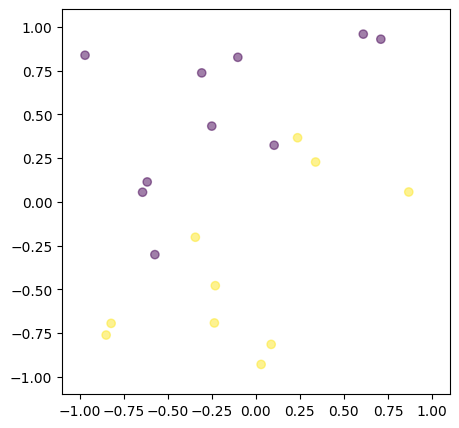

In [90]:
import numpy as np
import matplotlib.pyplot as plt

def createDataset(n=20, vector=[1,-1], bias=0.2):
  X = np.random.uniform(size=(n,2))*2-1
  y = (X@vector + bias>0)*2-1
  return X, y

X, y = createDataset()

def plotDataset(X, y):
  plt.figure(figsize=(5,5))
  plt.scatter(X[:,0], X[:,1], c=y, cmap="viridis", alpha=0.5)
  plt.xlim(-1.1, 1.1)
  plt.ylim(-1.1, 1.1)

plotDataset(X, y)
plt.show()

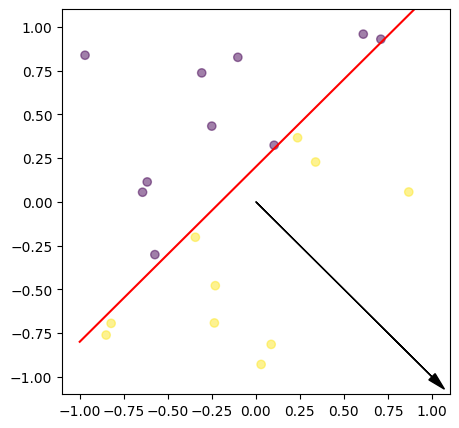

In [108]:
def plotHyperplan(vector, bias):
  xs = np.array([-1,1])
  ys = -(vector[0]*xs + bias)/vector[1]
  plt.plot(xs, ys, 'r')

def plotVector(vector):
  plt.arrow(0, 0, vector[0], vector[1], head_width=0.05, head_length=0.1, fc='k', ec='k')

plotDataset(X, y)
vector = [1,-1]
bias = 0.2
plotHyperplan(vector, bias)
plotVector(vector)
plt.show()

Accuracy: 0.9
Weights: [  7.52809506 -11.08360014], bias: 0


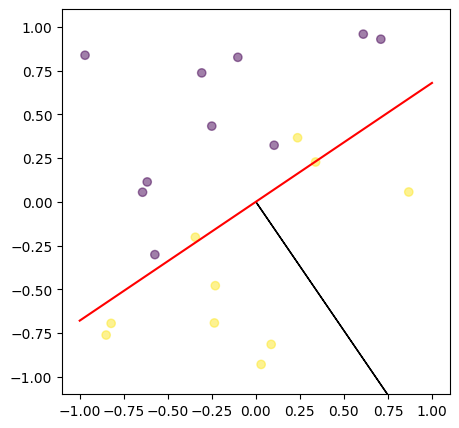

In [110]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

def sign(a):
  return (a>0)*2-1

class Perceptron(BaseEstimator, ClassifierMixin):
  def __init__(self, max_iter=10):
    self.max_iter = max_iter

  def fit(self, X, y):
    self.w = np.random.uniform(size=(X.shape[1],))
    self.b = 0 #np.random.uniform()
    for _ in range(self.max_iter):
      cost = 0
      y_pred = self.predict(X)
      error = y - y_pred
      self.w += X.T@error
      cost = np.sum(error**2)
      if cost == 0:
        break
    return self

  def predict(self, X):
    logits = X@self.w + self.b
    y_pred = sign(logits)
    return y_pred

clf = Perceptron()
clf.fit(X, y)
y_pred = clf.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: {clf.w}, bias: {clf.b}")

plotDataset(X, y)
plotHyperplan(clf.w, clf.b)
plotVector(clf.w)
plt.show()


Accuracy: 1.0
Weights: [ 12.83141152 -14.49602322], bias: 2.4835047538055726


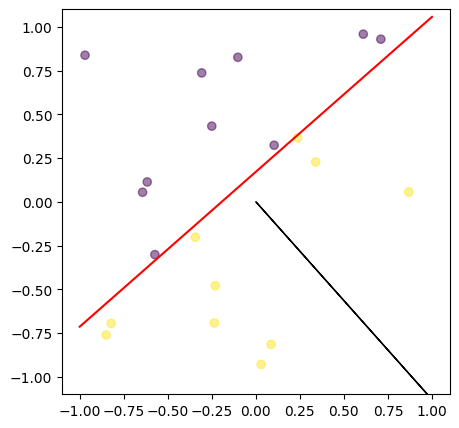

In [111]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

def sign(a):
  return (a>0)*2-1

class Perceptron(BaseEstimator, ClassifierMixin):
  def __init__(self, max_iter=100):
    self.max_iter = max_iter

  def fit(self, X, y):
    self.w = np.random.uniform(size=(X.shape[1],))
    self.b = np.random.uniform()
    for _ in range(self.max_iter):
      cost = 0
      y_pred = self.predict(X)
      error = y - y_pred
      self.w += X.T@error
      self.b += np.sum(error)
      cost = np.sum(error**2)
      if cost == 0:
        break
    return self

  def predict(self, X):
    logits = X@self.w + self.b
    y_pred = sign(logits)
    return y_pred

clf = Perceptron()
clf.fit(X, y)
y_pred = clf.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: {clf.w}, bias: {clf.b}")

plotDataset(X, y)
plotHyperplan(clf.w, clf.b)
plotVector(clf.w)
plt.show()


Accuracy: 0.982


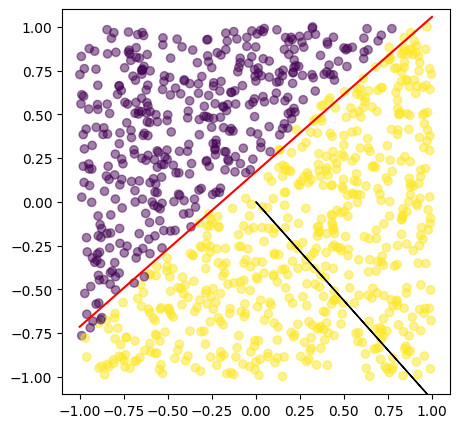

In [113]:
X_test, y_test = createDataset(1000)
y_pred = clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
plotDataset(X_test, y_test)
plotHyperplan(clf.w, clf.b)
plotVector(clf.w)
plt.show()